<h1 align="center">Laboratorio 4</h1>

## Información

**Integrantes:**

| Name              | Institution ID | GitHub User |
| ----------------- | -------------- | ----------- |
| Josué Say         | 22801          | JosueSay    |
| Carlos Valladares | 221164         | vgcarlol    |

- [Repositorio](https://github.com/JosueSay/intro-to-computer-vision/tree/main/labs/lab4)

## Preparación de entorno

In [2]:
# %pip install -r requirements.txt
# jupyter nbconvert lab4.ipynb --to html

## Librerías y Configuración

In [3]:
import cv2, math, os, random, json
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

logs = {}

In [4]:
def addLog(section, key, value):
    global logs
    if section not in logs:
        logs[section] = {}
    logs[section][key] = value

In [5]:
def saveLogsAsJSON(logs_dict, filename):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(logs_dict, f, indent=4)
    print(f"Logs guardados en: {filename}")

## Task 1

El objetivo es evaluar la comprensión de la geometría proyectiva y la manipulación algebraica de coordenadas homogéneas. Entonces, responda las siguientes preguntas demostrando el desarrollo matemático. No se aceptan respuestas puramente textuales sin respaldo algebraico.

### Inciso 1

Una homografía $H$ es una matriz de $3 \times 3$. Explique matemáticamente por qué, aunque tiene 9 elementos, solo posee 8 grados de libertad (GDL)

**Respuesta:**

Teniendo la homografía:

$$
H=
\begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33}
\end{bmatrix},
\quad
\mathbf{x}=
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix},
\quad
\mathbf{x'} \sim H\mathbf{x}
$$


En coordenadas homogéneas como una equivalencia de escala:

$$
\mathbf{x}\sim \lambda\mathbf{x},\ \lambda\neq 0
$$

Entonces para cualquier $\alpha\neq 0$:

$$
\mathbf{x'}\sim H\mathbf{x}\ \Rightarrow\ \mathbf{x'}\sim (\alpha H)\mathbf{x}
$$

porque el resultado homogéneo final se normaliza dividiendo por la tercera coordenada. Es decir, (H) está definida hasta escala:

$$
H \sim \alpha H
$$

Esto introduce una ambigüedad de 1 parámetro (la escala global), así que:

$$
\text{GDL}(H)=9-1=8
$$

#### Inciso a

Adicionalmente, responda. Si tuviéramos una cámara que solo rota sobre su eje óptico (sin traslación ni cambio de perspectiva), ¿la matriz de transformación sigue teniendo 8 GDL o se reduce? Demuestre la estructura de dicha matriz simplificada.

**Respuesta:**

Si la cámara solo rota alrededor del eje óptico, en el plano imagen eso es una isometría 2D centrada en el punto principal.

> isometría = rotación + traslación (3 GDL). Se restringe a una sola rotación y el centro está fijado por intrínsecos.

En forma homogénea, una rotación 2D alrededor del origen es:

$$
R(\theta)=
\begin{bmatrix}
\cos\theta & -\sin\theta & 0\
\sin\theta & \cos\theta & 0\
0&0&1
\end{bmatrix}.
$$

Pero rotar alrededor del **punto principal** $c_x,c_y$:

$$
T(c_x,c_y)=
\begin{bmatrix}
1&0&c_x\
0&1&c_y\
0&0&1
\end{bmatrix},\quad
T(-c_x,-c_y)=
\begin{bmatrix}
1&0&-c_x\
0&1&-c_y\
0&0&1
\end{bmatrix}.
$$

Entonces la transformación en la imagen es:

$$
H_{\text{roll}} = T(c_x,c_y), R(\theta), T(-c_x,-c_y).
$$

Al expander queda la multiplicación directa:

$$
H_{\text{roll}}=
\begin{bmatrix}
\cos\theta & -\sin\theta & c_x - c_x\cos\theta + c_y\sin\theta\
\sin\theta & \cos\theta & c_y - c_x\sin\theta - c_y\cos\theta\
0&0&1
\end{bmatrix}.
$$


- Es afín/isométrica (tercera fila $[0\ 0\ 1]$ => sin componente proyectiva).
- Los parámetros libres aquí son solo $\theta$ (si $c_x,c_y$ se consideran parte de (K) y fijos).

Ya no son 8 GDL, se reduce. En el caso ideal “solo roll, sin traslación ni perspectiva”:

$$
\text{GDL} = 1\ (\theta).
$$

### Inciso 2

En el algoritmo DLT (Direct Linear Transform), convertimos el problema $x' = Hx$ en un sistema de la forma $Ah = 0.$

Explique por qué buscamos el vector singular asociado al menor valor singular de $A$ en lugar de simplemente invertir la matriz. ¿Qué representa geométricamente ese "menor valor singular" cuando los datos tienen ruido?

**Respuesta:**

DLT transforma:

$$
\mathbf{x'} \sim H\mathbf{x}
$$

a un sistema homogéneo:

$$
A\mathbf{h} = 0,
$$

donde $\mathbf{h}$ apila los 9 parámetros de $H$.

**No se puede “invertir” porque no es (Ax=b)**

No es un vector $b\neq 0$, es un sistema homogéneo. La solución trivial siempre existe:

$$
\mathbf{h}=0
$$

y no sirve. Además, $A$ típicamente es $2N\times 9$; no es cuadrada => **no es invertible**.

Por eso se impone la restricción:

$$
|\mathbf{h}|=1
$$

y se resuelve el problema de mínimos cuadrados:

$$
\min_{|\mathbf{h}|=1} |A\mathbf{h}|
$$

**¿Por qué el menor valor singular?**

Usando SVD:

$$
A = U\Sigma V^T
$$

Entonces:

$$
|A\mathbf{h}| = |U\Sigma V^T \mathbf{h}| = |\Sigma (V^T\mathbf{h})|
$$

porque $U$ es ortonormal y preserva norma.

Si definimos:

$$
\mathbf{y}=V^T\mathbf{h},\quad |\mathbf{y}|=|\mathbf{h}|=1
$$

entonces:

$$
|A\mathbf{h}|^2 = |\Sigma \mathbf{y}|^2
= \sum_{i} \sigma_i^2, y_i^2
$$

Para minimizar esto con $|\mathbf{y}|=1$, conviene poner toda la "energía" en el componente con $(\sigma_i)$ más pequeño, o sea el menor valor singular. Por eso:

$$
\mathbf{h} = \mathbf{v}_{\min}
$$

**Interpretación geométrica con ruido**

Con ruido, ya no existe $\mathbf{h}$ tal que $A\mathbf{h}=0$. El menor valor singular $\sigma_{\min}$ mide qué tan cerca está el sistema de tener un nullspace perfecto de dimensión 1 para esa solución o equivalentemente, el residuo mínimo alcanzable:

$$
\min_{|\mathbf{h}|=1}|A\mathbf{h}| = \sigma_{\min}
$$

### Inciso 3

Si usted selecciona 4 puntos para calcular $H$, pero 3 de ellos son colineales (están en la misma línea recta), el algoritmo fallará.

Explique algebraicamente qué le sucede a la matriz $A$ del sistema DLT en este caso y por qué no tiene solución única.

**Respuesta:**

En DLT para homografía, cada correspondencia aporta 2 ecuaciones => con 4 puntos:

$$
A\in \mathbb{R}^{8\times 9}
$$

Para una solución única (hasta escala), queremos que el espacio nulo sea 1D:

$$
\dim(\mathcal{N}(A)) = 1
\ \Longleftrightarrow
\operatorname{rank}(A)=8
$$

**Colinealidad => pérdida de rango**

Si 3 puntos $\mathbf{x}_1,\mathbf{x}_2,\mathbf{x}_3$ son colineales, existe una recta $\mathbf{l}$ tal que:

$$
\mathbf{l}^T \mathbf{x}_i = 0,\quad i=1,2,3
$$

Esto induce dependencias lineales en las ecuaciones que se apilan en $A$; varias filas construidas desde esos puntos se vuelven linealmente dependientes, porque la geometría no excita todos los parámetros de $H$.

Resultado:

$$
\operatorname{rank}(A) < 8
\quad \Rightarrow\quad
\dim(\mathcal{N}(A)) = 9-\operatorname{rank}(A) > 1
$$

O sea, hay infinitas soluciones $\mathbf{h}$ (no solo una dirección), por lo que $H$ no queda determinada de manera única.

## Task 2

El objetivo de esta parte es implementar el pipeline de alineación sin depender de cajas negras. Por ello considere que no deben de usar cv2.findHomography o cv2.RANSAC. Además para este laboratorio necesitará crear su propio dataset, por ello tome 3 fotografías propias de una escena planar (i.e. una pancarta en una pared, un cuadro, o una fachada de edificio lejana) con ángulos y perspectivas drásticamente diferentes. Con esto realice:

### Constantes

In [6]:
IMAGE_PATHS = [
    "images/libro_front.png",
    "images/libro_der.png",
    "images/libro_izq.png"
]

GRID_COLS = 3

SIFT_N_FEATURES = 2000
SIFT_MAX_KEYPOINTS_DRAW = 300

MATCH_METHOD = "SIFT"
MATCH_CROSS_CHECK = False

RANSAC_UMBRAL_PX = 3.0
RANSAC_PROB_EXITO = 0.99
RANSAC_SEED = 42
RANSAC_MIN_ITERATIONS = 50
RANSAC_MAX_ITERATIONS = 5000

FIGSIZE_KP = (8, 8)
FIGSIZE_STITCH = (16, 8)

RUN_NAME = "run_experiment_01"
LOG_JSON_PATH = f"{RUN_NAME}.json"

In [7]:
def loadConvertImageToGray(imagePaths, gridCols=3):
    grayImages = {}

    numImages = len(imagePaths)
    gridRows = math.ceil(numImages / gridCols)

    plt.figure(figsize=(6 * gridCols, 6 * gridRows))

    for idx, imagePath in enumerate(imagePaths):
        if not os.path.exists(imagePath):
            raise FileNotFoundError(f"No se encontró la imagen: {imagePath}")

        imageColor = cv2.imread(imagePath)
        if imageColor is None:
            raise IOError(f"No se pudo cargar la imagen: {imagePath}")

        imageGray = cv2.cvtColor(imageColor, cv2.COLOR_BGR2GRAY)
        imageName = os.path.basename(imagePath)
        grayImages[imageName] = imageGray

        plt.subplot(gridRows, gridCols, idx + 1)
        plt.imshow(imageGray, cmap="gray")
        plt.title(imageName)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    addLog("dataset", "image_paths", imagePaths)
    addLog("dataset", "image_names", list(grayImages.keys()))

    return grayImages

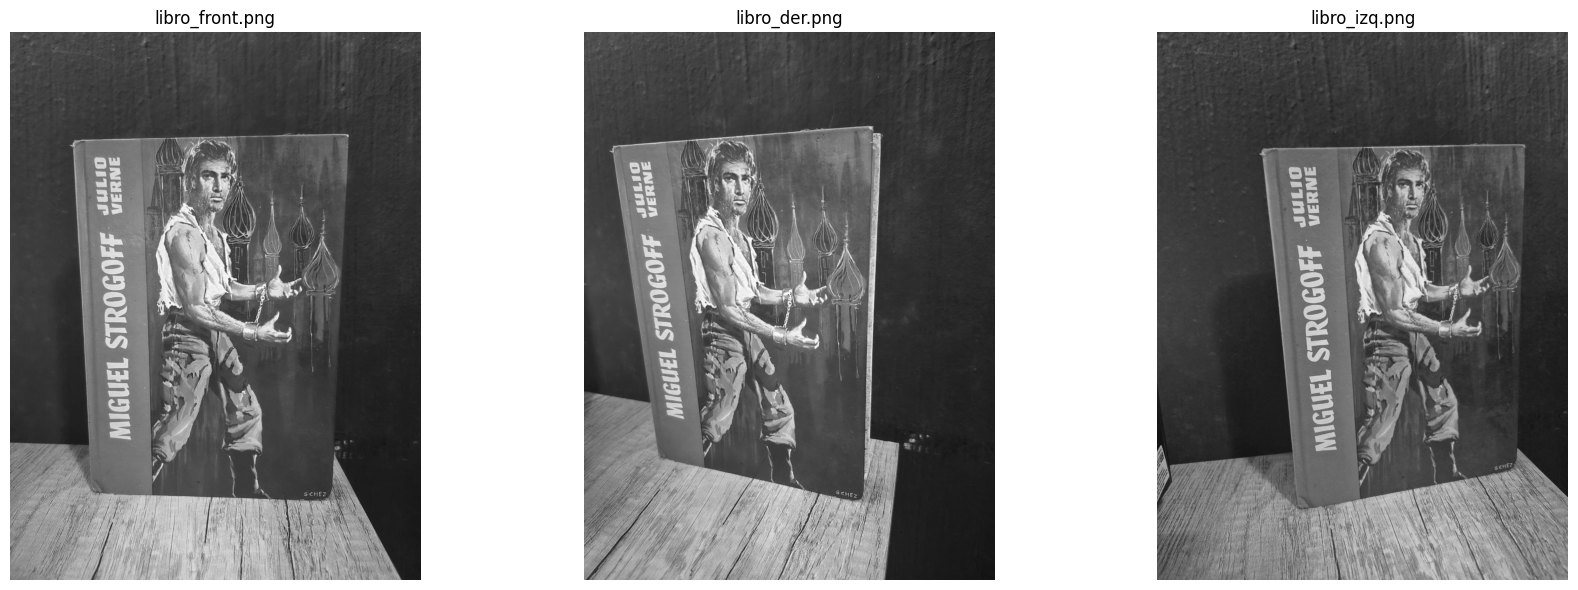

In [8]:
grayImages = loadConvertImageToGray(IMAGE_PATHS, gridCols=GRID_COLS)

image_names = [os.path.basename(p) for p in IMAGE_PATHS]
image_grays = [grayImages[name] for name in image_names]

img1Gray = image_grays[0]
img2Gray = image_grays[1]
img3Gray = image_grays[2]

### Inciso 1 - Detección y Macheo

#### Inciso a

Utilice SIFT u ORB (permitido usar OpenCV aquí) para detectar puntos de interés y descriptores.

In [9]:
"""
Justificación
- Necesitamos correspondencias para luego estimar una homografía
- SIFT produce descriptores de 128 dimensiones (invariantes a escala y rotación)
- Estamos en etapa pre-geométrica (todavía no usamos modelo proyectivo)
"""

def detectDescribeSIFT(
    image_gray,
    image_name="image",
    n_features=2000,
    show_plot=True,
    max_keypoints_to_draw=300,
    enable_logs=True
):
    sift = cv2.SIFT_create(nfeatures=n_features)
    keypoints, descriptors = sift.detectAndCompute(image_gray, None)

    if enable_logs:
        addLog(f"sift_{image_name}", "image_shape", list(image_gray.shape))
        addLog(f"sift_{image_name}", "num_keypoints", int(len(keypoints)))
        addLog(f"sift_{image_name}", "descriptor_shape", None if descriptors is None else list(descriptors.shape))

    if show_plot:
        image_kp = cv2.drawKeypoints(
            image_gray,
            keypoints[:max_keypoints_to_draw],
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        )
        plt.figure(figsize=FIGSIZE_KP)
        plt.imshow(image_kp, cmap="gray")
        plt.title(f"SIFT Keypoints - {image_name}")
        plt.axis("off")
        plt.show()

    return keypoints, descriptors

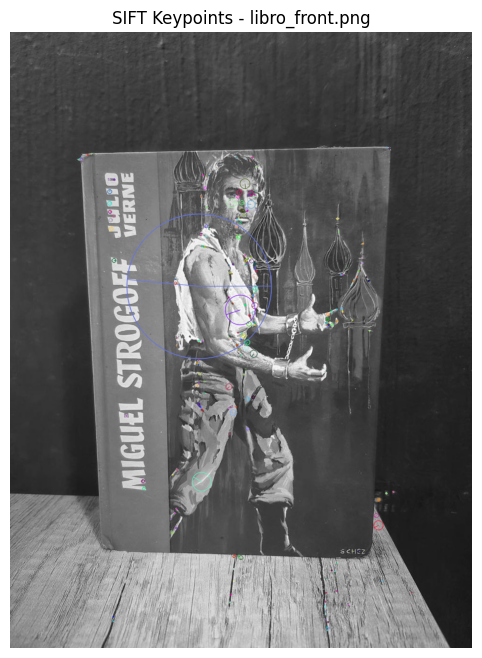

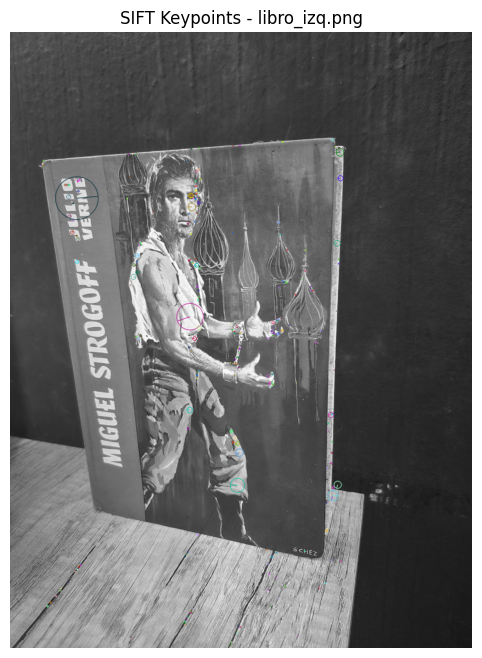

In [10]:
kp1, desc1 = detectDescribeSIFT(
    img1Gray,
    image_name=image_names[0],
    n_features=SIFT_N_FEATURES,
    show_plot=True,
    max_keypoints_to_draw=SIFT_MAX_KEYPOINTS_DRAW,
    enable_logs=True
)

kp2, desc2 = detectDescribeSIFT(
    img2Gray,
    image_name=image_names[2],
    n_features=SIFT_N_FEATURES,
    show_plot=True,
    max_keypoints_to_draw=SIFT_MAX_KEYPOINTS_DRAW,
    enable_logs=True
)

#### Inciso b

Realice un emparejamiento de fuerza bruta (Brute-Force Matcher).

In [11]:
"""
Justificación:

- Matching directo descriptor <-> descriptor
- Distancia Euclidiana (porque SIFT usa NORM_L2)
- Queremos visualizar el ruido explícitamente
"""

def matchDescriptorsBF(
    descriptors_1,
    descriptors_2,
    method="SIFT",
    cross_check=True,
    enable_logs=True
):
    if method == "SIFT":
        norm_type = cv2.NORM_L2
    elif method == "ORB":
        norm_type = cv2.NORM_HAMMING
    else:
        raise ValueError("Metodo no soportado")

    matcher = cv2.BFMatcher(norm_type, crossCheck=cross_check)
    matches = matcher.match(descriptors_1, descriptors_2)
    matches = sorted(matches, key=lambda x: x.distance)

    if enable_logs:
        addLog("matching", "method", method)
        addLog("matching", "cross_check", cross_check)
        addLog("matching", "total_matches", int(len(matches)))
        addLog("matching", "top10_distances", [float(m.distance) for m in matches[:10]])

    return matches

In [12]:
bf_matches = matchDescriptorsBF(
    desc1,
    desc2,
    method=MATCH_METHOD,
    cross_check=MATCH_CROSS_CHECK,
    enable_logs=True
)

#### Inciso c

Requisito: Visualice los matches antes de filtrar. Debe verse una cantidad considerable de ruido/errores.

**Análisis:**

Al visualizar los matches sin ningún filtrado geométrico:

- Puntos conectados incorrectamente
- Correspondencias que no respetan una transformación proyectiva coherente

La razón es que:

**Matching != Geometría**

El matching con SIFT + Brute Force es un proceso puramente descriptivo.
Cada correspondencia se establece únicamente en función de la similitud entre descriptores (distancia euclidiana en el espacio de características), sin imponer ninguna restricción geométrica global.

Es decir, el criterio es:

$$
\min_j | d_i - d_j |
$$

pero no se exige consistencia con un modelo espacial.

Esto corresponde exactamente a:

- Semana 4: Descriptores locales
- Inicio de Semana 5: Antes de introducir homografía

Aquí se evidencia el problema central:

No podemos aplicar mínimos cuadrados directamente sobre todas las correspondencias porque el conjunto contiene muchos outliers.

En términos algebraicos, resolver

$$
Ah = 0
$$

### Inciso 2 - Algoritmo DLT

- Escriba una función calcular_homografia_dlt(puntos_src, puntos_dst) que reciba exactamente 4 pares de puntos.
- Debe construir la matriz $A$ de tamaño $8 \times 9$.
- Debe resolver el sistema usando SVD (numpy.linalg.svd).
- Nota: Debe normalizar los puntos antes de entrar al DLT (restar la media y dividir por la desviación estándar) para estabilidad numérica, y des-normalizar la matriz $H$ resultante.

**Justificación:**

Queremos estimar una matriz $H$ tal que $\mathbf{x'} \sim H\mathbf{x}$, lo que conduce a un sistema homogéneo $A\mathbf{h}=0$ donde $\mathbf{h}$ contiene los 9 parámetros de $H$ y está definido hasta una escala (8 grados de libertad reales). Cada correspondencia aporta dos ecuaciones lineales, por lo que 4 pares generan una matriz $A \in \mathbb{R}^{8\times 9}$, el mínimo necesario para resolver el problema. La solución no trivial se obtiene imponiendo la restricción $|\mathbf{h}|=1$ y resolviendo mediante SVD, tomando el vector singular derecho asociado al menor valor singular, lo que minimiza $|A\mathbf{h}|$ en sentido de mínimos cuadrados. La normalización previa (restar media y dividir por desviación estándar) responde a la regla de estabilidad numérica discutida en tus apuntes: sin normalizar, la matriz $A$ puede volverse mal condicionada y degradar la descomposición SVD; por ello se transforman los puntos antes de estimar $H$ y posteriormente se des-normaliza mediante $H_{final} = T_{dst}^{-1} H T_{src}$, preservando la coherencia proyectiva.

In [13]:
def normalizePointsStd(points_xy, enable_logs=False, label="points"):
    """
    Normaliza puntos 2D (Nx2) con:
    - restar media (por eje)
    - dividir por desviación estándar (por eje)
    Devuelve:
    - points_norm (Nx2)
    - T (3x3) tal que x_norm ~ T x
    """
    points_xy = np.asarray(points_xy, dtype=np.float64)

    mean_xy = points_xy.mean(axis=0)
    std_xy = points_xy.std(axis=0)

    eps = 1e-12
    std_xy = np.where(std_xy < eps, 1.0, std_xy)

    points_norm = (points_xy - mean_xy) / std_xy

    T = np.array([
        [1.0 / std_xy[0], 0.0, -mean_xy[0] / std_xy[0]],
        [0.0, 1.0 / std_xy[1], -mean_xy[1] / std_xy[1]],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)

    if enable_logs:
        addLog(f"normalization_{label}", "mean", mean_xy.tolist())
        addLog(f"normalization_{label}", "std", std_xy.tolist())

    return points_norm, T

In [14]:
def buildMatrixA(puntos_src_norm, puntos_dst_norm):
    """
    Construye A (8x9) para 4 pares normalizados.
    DLT clásico con restricciones x' ~ H x
    """
    A_rows = []
    for (x, y), (u, v) in zip(puntos_src_norm, puntos_dst_norm):
        # ecuaciones por correspondencia
        # [-x, -y, -1,  0,  0,  0,  u*x, u*y, u]
        # [ 0,  0,  0, -x, -y, -1,  v*x, v*y, v]
        A_rows.append([-x, -y, -1,  0,  0,  0,  u*x, u*y, u])
        A_rows.append([ 0,  0,  0, -x, -y, -1,  v*x, v*y, v])

    A = np.asarray(A_rows, dtype=np.float64)
    return A

In [15]:
def calcular_homografia_dlt(puntos_src, puntos_dst, enable_logs=False):
    puntos_src = np.asarray(puntos_src, dtype=np.float64)
    puntos_dst = np.asarray(puntos_dst, dtype=np.float64)

    src_norm, T_src = normalizePointsStd(puntos_src, enable_logs, "src")
    dst_norm, T_dst = normalizePointsStd(puntos_dst, enable_logs, "dst")

    A = buildMatrixA(src_norm, dst_norm)

    _, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H_norm = h.reshape(3, 3)

    H = np.linalg.inv(T_dst) @ H_norm @ T_src

    if abs(H[2, 2]) > 1e-12:
        H = H / H[2, 2]

    if enable_logs:
        addLog("DLT", "A_shape", list(A.shape))
        addLog("DLT", "singular_values", S.tolist())
        addLog("DLT", "H_final", H.tolist())

    return H

### Inciso 3 - RANSAC Manual

- Implemente la función ransac_homografia(matches, umbral, prob_exito).
- Cálculo de N: Su código debe calcular dinámicamente el número de iteraciones $N$ basado en la fórmula de probabilidad vista en clase. No "hardcodee" el número 1000.
- Bucle
  - Seleccione 4 matches aleatorios.
  - Llame a su función DLT.
  - Proyecte todos los puntos fuente usando H_test.
  - Calcule el error de reproyección (distancia Euclidiana) y cuente los inliers.
- Refinamiento: Una vez encontrado el mejor conjunto de inliers, recalcule $H$ final usando todos los inliers (no solo los 4 iniciales) mediante SVD.

> La salida esperada es una imagen “stitched” (panorama) mostrando la alineación correcta.

In [16]:
def extractMatchedPoints(matches, keypoints_src, keypoints_dst):
    """
    Convierte lista de cv2.DMatch -> arrays Nx2 de puntos (src, dst).
    src = imagen 1, dst = imagen 2 (según cómo matcheaste).
    """
    puntos_src = []
    puntos_dst = []

    for m in matches:
        x_src, y_src = keypoints_src[m.queryIdx].pt
        x_dst, y_dst = keypoints_dst[m.trainIdx].pt
        puntos_src.append([x_src, y_src])
        puntos_dst.append([x_dst, y_dst])

    return np.asarray(puntos_src, dtype=np.float64), np.asarray(puntos_dst, dtype=np.float64)

In [17]:
def projectPointsHomography(points_xy, H):
    """
    Proyecta puntos Nx2 usando H: x' ~ Hx.
    Retorna puntos Nx2 en coordenadas cartesianas.
    """
    points_xy = np.asarray(points_xy, dtype=np.float64)
    ones = np.ones((points_xy.shape[0], 1), dtype=np.float64)
    points_h = np.hstack([points_xy, ones])

    proj_h = (H @ points_h.T).T
    w = proj_h[:, 2:3]
    w = np.where(np.abs(w) < 1e-12, 1e-12, w)

    proj_xy = proj_h[:, 0:2] / w
    return proj_xy

In [18]:
def reprojectionErrors(points_src_xy, points_dst_xy, H):
    """
    Error euclidiano por punto: || x_dst - project(H, x_src) ||_2
    """
    proj_xy = projectPointsHomography(points_src_xy, H)
    diff = points_dst_xy - proj_xy
    errors = np.linalg.norm(diff, axis=1)
    return errors

Inliers se definen por reproyección:

$$
|\mathbf{x'} - H\mathbf{x}| < \text{umbral}
$$

In [19]:
def computeRansacIterations(prob_exito, outlier_ratio, sample_size=4):
    """
    Calcula N dinámicamente con:
    N = log(1-p) / log(1 - (1-e)^s)
    e = outlier_ratio, s = sample_size.
    """
    p = float(prob_exito)
    e = float(outlier_ratio)
    s = int(sample_size)

    p = min(max(p, 1e-12), 1 - 1e-12)
    e = min(max(e, 0.0), 0.999999)

    inlier_prob = (1.0 - e) ** s
    denom = math.log(1.0 - inlier_prob)

    if abs(denom) < 1e-12:
        return 1

    N = math.log(1.0 - p) / denom
    return int(math.ceil(N))

Fórmula con (s=4):
$$
N = \frac{\log(1-p)}{\log(1-(1-e)^s)}
$$

En código, como (e) (outliers) no se conoce al inicio, usamos la estimación por iteración con el mejor ratio de inliers observado.

In [20]:
def ransac_homografia(
    matches,
    umbral,
    prob_exito,
    keypoints_src,
    keypoints_dst,
    seed=42,
    min_iterations=50,
    max_iterations=5000,
    enable_logs=True
):
    random.seed(seed)
    np.random.seed(seed)

    points_src_all, points_dst_all = extractMatchedPoints(
        matches, keypoints_src, keypoints_dst
    )
    n_total = points_src_all.shape[0]

    # cálculo dinámico de N usando la fórmula vista en clase
    outlier_ratio_est = 0.9
    N = computeRansacIterations(prob_exito, outlier_ratio_est, sample_size=4)
    N = max(N, min_iterations)
    N = min(N, max_iterations)

    best_H = None
    best_inlier_mask = None
    best_inlier_count = 0

    inlier_history = []

    # bucle RANSAC
    for i in range(N):

        # Inciso c.i: seleccionar 4 matches aleatorios
        sample_idx = random.sample(range(n_total), 4)
        sample_src = points_src_all[sample_idx]
        sample_dst = points_dst_all[sample_idx]

        # estimar H_test con DLT (4 puntos)
        try:
            H_test = calcular_homografia_dlt(sample_src, sample_dst, enable_logs=False)
        except Exception:
            continue

        # proyectar todos los puntos fuente con H_test y calcular error de reproyección y contar inliers
        errors = reprojectionErrors(points_src_all, points_dst_all, H_test)
        inlier_mask = errors < float(umbral)
        inlier_count = int(np.sum(inlier_mask))

        inlier_history.append(inlier_count)

        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inlier_mask = inlier_mask
            best_H = H_test

    if best_H is None:
        raise RuntimeError("RANSAC no encontró una homografía válida")

    if enable_logs:
        addLog("ransac", "seed", int(seed))
        addLog("ransac", "umbral_px", float(umbral))
        addLog("ransac", "prob_exito", float(prob_exito))
        addLog("ransac", "iterations", int(N))
        addLog("ransac", "total_matches", int(n_total))
        addLog("ransac", "best_inliers", int(best_inlier_count))
        addLog("ransac", "inlier_ratio", float(best_inlier_count / n_total))
        addLog("ransac", "inlier_history", [int(x) for x in inlier_history])

    return best_H, best_inlier_mask, best_inlier_count

In [21]:
def refineHomographyWithInliers(
    points_src_all,
    points_dst_all,
    inlier_mask,
    enable_logs=True
):
    inlier_src = points_src_all[inlier_mask]
    inlier_dst = points_dst_all[inlier_mask]

    n_inliers = int(inlier_src.shape[0])
    if n_inliers < 4:
        raise RuntimeError("Refinamiento: menos de 4 inliers, no se puede recalcular H")

    src_norm, T_src = normalizePointsStd(inlier_src, enable_logs=False, label="ref_src")
    dst_norm, T_dst = normalizePointsStd(inlier_dst, enable_logs=False, label="ref_dst")

    A_rows = []
    for (x, y), (u, v) in zip(src_norm, dst_norm):
        A_rows.append([-x, -y, -1,  0,  0,  0,  u*x, u*y, u])
        A_rows.append([ 0,  0,  0, -x, -y, -1,  v*x, v*y, v])

    A = np.asarray(A_rows, dtype=np.float64)

    # Ah = 0 -> solución: última fila de Vt (menor valor singular)
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    H_norm = h.reshape(3, 3)

    H_ref = np.linalg.inv(T_dst) @ H_norm @ T_src
    if abs(H_ref[2, 2]) > 1e-12:
        H_ref = H_ref / H_ref[2, 2]

    if enable_logs:
        addLog("refine", "num_inliers", int(n_inliers))
        addLog("refine", "A_shape", [int(A.shape[0]), int(A.shape[1])])
        addLog("refine", "singular_values", S.tolist())
        addLog("refine", "H_final", H_ref.tolist())

    return H_ref

Se recalcula la homografía usando todos los inliers mediante SVD sobre una matriz $A \in \mathbb{R}^{2N \times 9}$, reduciendo el error de mínimos cuadrados y estabilizando la estimación respecto al modelo obtenido con 4 puntos.


In [22]:
addLog("config", "SIFT_N_FEATURES", SIFT_N_FEATURES)
addLog("config", "MATCH_METHOD", MATCH_METHOD)
addLog("config", "MATCH_CROSS_CHECK", MATCH_CROSS_CHECK)
addLog("config", "RANSAC_UMBRAL_PX", RANSAC_UMBRAL_PX)
addLog("config", "RANSAC_PROB_EXITO", RANSAC_PROB_EXITO)

H_12, inlier_mask, inlier_count = ransac_homografia(
    matches=bf_matches,
    umbral=RANSAC_UMBRAL_PX,
    prob_exito=RANSAC_PROB_EXITO,
    keypoints_src=kp1,
    keypoints_dst=kp2,
    seed=RANSAC_SEED,
    min_iterations=RANSAC_MIN_ITERATIONS,
    max_iterations=RANSAC_MAX_ITERATIONS,
    enable_logs=True
)

points_src_all, points_dst_all = extractMatchedPoints(bf_matches, kp1, kp2)

H_12_ref = refineHomographyWithInliers(
    points_src_all=points_src_all,
    points_dst_all=points_dst_all,
    inlier_mask=inlier_mask,
    enable_logs=True
)

In [23]:
def computePanoramaCanvas(src_shape, dst_shape, H_src_to_dst):
    h_src, w_src = src_shape
    h_dst, w_dst = dst_shape

    src_corners = np.array([
        [0, 0],
        [w_src - 1, 0],
        [w_src - 1, h_src - 1],
        [0, h_src - 1]
    ], dtype=np.float64)

    dst_corners = np.array([
        [0, 0],
        [w_dst - 1, 0],
        [w_dst - 1, h_dst - 1],
        [0, h_dst - 1]
    ], dtype=np.float64)

    src_corners_warped = projectPointsHomography(src_corners, H_src_to_dst)
    all_corners = np.vstack([dst_corners, src_corners_warped])

    min_xy = all_corners.min(axis=0)
    max_xy = all_corners.max(axis=0)

    tx = -min_xy[0] if min_xy[0] < 0 else 0.0
    ty = -min_xy[1] if min_xy[1] < 0 else 0.0

    T = np.array([
        [1.0, 0.0, tx],
        [0.0, 1.0, ty],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)

    canvas_w = int(np.ceil(max_xy[0] + tx)) + 1
    canvas_h = int(np.ceil(max_xy[1] + ty)) + 1
    
    return (canvas_w, canvas_h), T

In [24]:
def stitchPanorama(image_src_gray, image_dst_gray, H_src_to_dst, enable_logs=True):
    (canvas_w, canvas_h), T = computePanoramaCanvas(
        src_shape=image_src_gray.shape,
        dst_shape=image_dst_gray.shape,
        H_src_to_dst=H_src_to_dst
    )

    H_canvas = T @ H_src_to_dst

    warped_src = cv2.warpPerspective(image_src_gray, H_canvas, (canvas_w, canvas_h))
    warped_dst = cv2.warpPerspective(image_dst_gray, T, (canvas_w, canvas_h))

    stitched = np.maximum(warped_dst, warped_src)

    if enable_logs:
        addLog("stitch", "canvas_size", [int(canvas_w), int(canvas_h)])

    return stitched

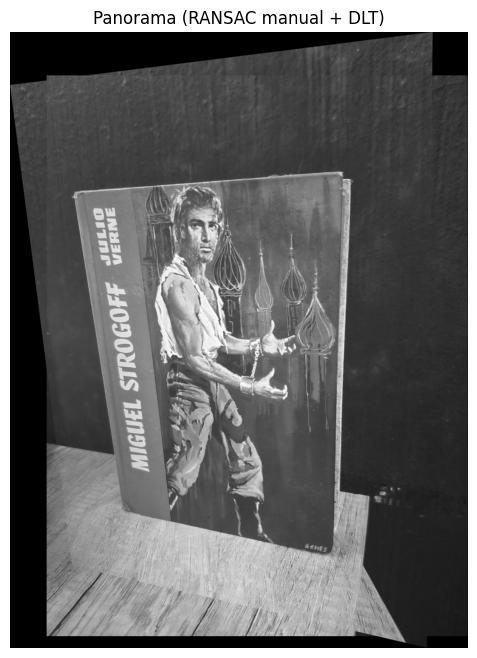

In [25]:
stitched = stitchPanorama(img1Gray, img2Gray, H_12_ref, enable_logs=True)

plt.figure(figsize=FIGSIZE_STITCH)
plt.imshow(stitched, cmap="gray")
plt.title("Panorama (RANSAC manual + DLT)")
plt.axis("off")
plt.show()

In [26]:
saveLogsAsJSON(logs, LOG_JSON_PATH)

Logs guardados en: run_experiment_01.json


## Task 3

En esta parte lo que se busca es evaluar el criterio profesional ante situaciones adversas y trade-offs de diseño. Para ello realice y responda lo siguiente

### Inciso 1

Ejecute su algoritmo RANSAC variando el parámetro de umbral de error (threshold) en pixeles (ej. 1px, 5px, 20px)

#### Inciso a

Genere una gráfica: Eje X = Umbral, Eje Y = Número de Inliers encontrados.

Threshold=1px -> Inliers=495
Threshold=5px -> Inliers=916
Threshold=20px -> Inliers=970


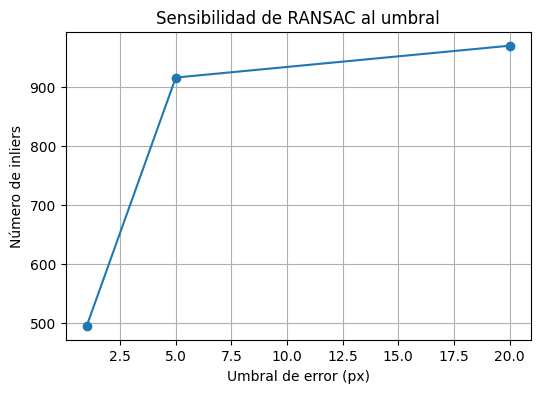

In [28]:
thresholds = [1, 5, 20]
inliers_counts = []

for t in thresholds:
    H_tmp, inlier_mask_tmp, inlier_count_tmp = ransac_homografia(
        matches=bf_matches,
        umbral=t,
        prob_exito=RANSAC_PROB_EXITO,
        keypoints_src=kp1,
        keypoints_dst=kp2,
        seed=RANSAC_SEED,
        min_iterations=RANSAC_MIN_ITERATIONS,
        max_iterations=RANSAC_MAX_ITERATIONS,
        enable_logs=False
    )

    inliers_counts.append(inlier_count_tmp)
    print(f"Threshold={t}px -> Inliers={inlier_count_tmp}")

# Gráfica

plt.figure(figsize=(6,4))
plt.plot(thresholds, inliers_counts, marker='o')
plt.xlabel("Umbral de error (px)")
plt.ylabel("Número de inliers")
plt.title("Sensibilidad de RANSAC al umbral")
plt.grid(True)
plt.show()


#### Inciso b

Discusión: Como ingeniero, ¿qué riesgo corre si establece un umbral demasiado estricto (ej. 0.5px)? ¿Qué pasa con la matriz final si el umbral es muy laxo (ej. 50px)?

La gráfica muestra que al incrementar el umbral de error de 1 px a 5 px se produce un aumento significativo en el número de inliers (de aproximadamente 495 a más de 900). Esto indica que un umbral demasiado estricto está descartando correspondencias válidas debido al ruido inherente en la detección de características y errores de cuantización.

Sin embargo, al aumentar el umbral de 5 px a 20 px, el incremento de inliers es marginal. Este comportamiento sugiere que el modelo ya capturó la mayoría de correspondencias correctas y que valores más altos del umbral comienzan a aceptar matches potencialmente incorrectos.

Como ingeniero, si se establece un umbral excesivamente estricto (por ejemplo 0.5 px), existe el riesgo de obtener muy pocos inliers, lo que puede producir una estimación inestable de la homografía. Por el contrario, un umbral demasiado laxo (por ejemplo 50 px) puede contaminar el conjunto de consenso con outliers, degradando la precisión geométrica de la matriz H y provocando distorsiones en el stitching.

Por lo tanto, la selección del umbral debe balancear robustez frente al ruido y capacidad de rechazo de outliers; en este experimento, valores cercanos a 5 px parecen ofrecer un compromiso adecuado.

### Inciso 2

Imagine que usted es el Lead Computer Vision Engineer de una empresa de drones. Deben alinear imágenes térmicas de paneles solares tomadas desde el aire para detectar fallos.

En este escenario se analiza la viabilidad de aplicar homografías y optimizaciones de RANSAC en un sistema real de inspección aérea de paneles solares. Se consideran tanto las limitaciones geométricas de la escena como las restricciones computacionales de la plataforma embebida.


#### Inciso a

Problema: El drone vuela a 50 metros de altura. El terreno no es perfectamente plano (hay colinas suaves), pero los paneles sí son planos.

El drone opera a una altura aproximada de 50 metros capturando imágenes térmicas. Aunque los paneles solares constituyen superficies planas, el terreno presenta variaciones suaves de elevación (colinas), lo que introduce cambios de profundidad en la escena observada. Este escenario rompe parcialmente el supuesto de planaridad global que requieren las homografías para modelar correctamente la geometría entre vistas.


#### Inciso b

Pregunta A: ¿Es válido usar una Homografía global para unir todo el mapa del terreno? ¿Por qué sí o por qué no?

No es válido utilizar una homografía global para unir todo el mapa del terreno. La homografía describe correctamente la relación entre dos vistas únicamente cuando la escena es planar o cuando la cámara experimenta rotación pura sin traslación.

En este caso, aunque los paneles solares individuales son planos, el terreno presenta colinas suaves que introducen variaciones de profundidad. Como consecuencia, diferentes regiones de la imagen siguen transformaciones proyectivas distintas.

Una única homografía global intentaría forzar un solo modelo geométrico sobre una escena que no es coplanar, lo que produciría errores de alineación, especialmente en zonas alejadas del plano dominante.

En la práctica, la homografía sería válida localmente sobre cada panel solar, pero no para todo el terreno. Una solución más robusta sería utilizar homografías locales por región, segmentar los paneles o emplear métodos más generales como mosaicing multi-plano o técnicas de Structure from Motion.


#### Inciso c

Pregunta B: Su algoritmo RANSAC está tardando demasiado (3 segundos por frame) en la computadora a bordo del drone (Raspberry Pi). La telemetría indica que el 90% de los matches iniciales son outliers debido al pasto y árboles repetitivos.

El principal problema es que aproximadamente el 90% de los matches iniciales son outliers. En este escenario, RANSAC requiere un número elevado de iteraciones para encontrar una muestra libre de outliers, lo que incrementa significativamente el tiempo de ejecución (≈3 segundos por frame).

Sin cambiar el hardware, la estrategia más efectiva es reducir la tasa de outliers antes de ejecutar RANSAC mediante pre-filtrado geométrico y mejora en la estimación de la proporción de inliers.

Una solución concreta incluye:

- aplicar el ratio test de Lowe para eliminar correspondencias ambiguas;
- filtrar matches por consistencia de orientación y escala entre keypoints;
- restringir la detección a regiones de interés donde se esperan paneles solares;
- ordenar matches por distancia del descriptor y priorizar los más confiables.

Además, es fundamental recalcular dinámicamente el número de iteraciones de RANSAC usando:

N = log(1 − p) / log(1 − w^s)

donde w es la proporción estimada de inliers. Si se incrementa w mediante pre-filtrado, el número de iteraciones necesarias disminuye exponencialmente, reduciendo el tiempo por frame sin modificar el hardware.

Este enfoque es especialmente crítico en plataformas embebidas como Raspberry Pi, donde el presupuesto computacional es limitado.


##### Inciso i

Proponga una estrategia concreta para reducir el tiempo de ejecución sin cambiar el hardware. (Pista: Piense en la fórmula de N o en pre-filtrado geométrico)

Estrategia concreta: reducir drásticamente el número de iteraciones de RANSAC aumentando la proporción de inliers (w) mediante pre-filtrado, y recalculando N dinámicamente.

1) Pre-filtrado para subir w (menos outliers antes de RANSAC):
- Aplicar Lowe ratio test (si se usa knnMatch) para eliminar matches ambiguos.
- Activar cross-check en BFMatcher (solo aceptar matches consistentes ida/vuelta).
- Filtrar por coherencia geométrica: descartar matches con diferencias extremas de escala y orientación entre keypoints.
- Restringir la detección a ROI donde están los paneles (evitar pasto/árboles), usando segmentación simple o máscara por umbral térmico.

2) N dinámico (menos iteraciones):
Con una estimación de w más alta, el número de iteraciones requeridas cae exponencialmente:
N = log(1 - p) / log(1 - w^s)
(donde s=4 para homografía).
En práctica: estimar w inicialmente (por ejemplo tras pre-filtrado o usando un N pequeño), calcular N, y cortar temprano si se alcanza un consenso suficientemente alto (early stopping).

Resultado: al reducir outliers (sube w) y recalcular N en lugar de usar un N fijo grande, el tiempo por frame baja notablemente sin cambiar hardware.